# Figure 5 visualization
Relationship between prediction loss and circular-structure complexity.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
DATA_DIR = PROJECT_ROOT / "data"

plt.rcParams.update({
    "axes.grid": False,
    "figure.figsize": (7, 4),
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 8,
})
COLORS = ["#cc3f40", "#bdccd4", "#0b2456", "#2980b9", "#00a043"]


In [2]:
data = np.load(DATA_DIR / 'figure5_structure_complexity_losses.npz')
print('keys:', data.files)
for key in data.files:
    print(key, data[key].shape)

keys: ['size', 'initial_prediction_error', 'optimized_prediction_error', 'improvement', 'number_of_parameters']
size (11,)
initial_prediction_error (11, 30)
optimized_prediction_error (11, 30)
improvement (11,)
number_of_parameters (11,)


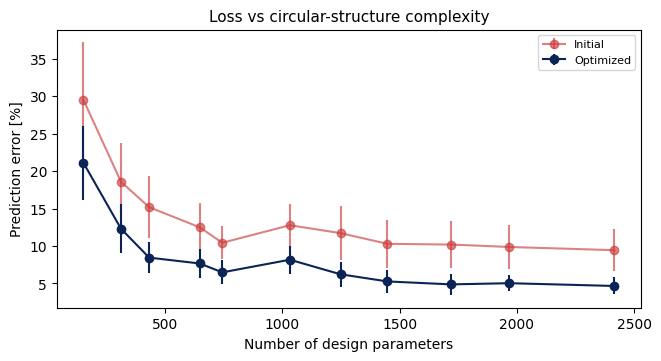

In [3]:
x = data['number_of_parameters']
init = data['initial_prediction_error']
opt = data['optimized_prediction_error']
fig, ax = plt.subplots(figsize=(6.5, 3.5), constrained_layout=True)
ax.errorbar(x, init.mean(axis=1), yerr=init.std(axis=1), marker='o', color=COLORS[0], alpha=0.65, label='Initial')
ax.errorbar(x, opt.mean(axis=1), yerr=opt.std(axis=1), marker='o', color=COLORS[2], label='Optimized')
ax.set_xlabel('Number of design parameters')
ax.set_ylabel('Prediction error [%]')
ax.set_title('Loss vs circular-structure complexity')
ax.legend()
plt.show()

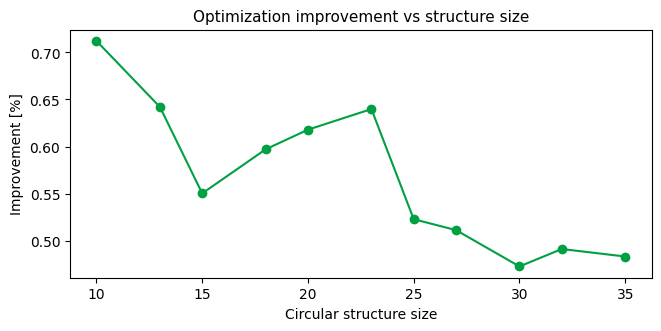

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 3.2), constrained_layout=True)
ax.plot(data['size'], data['improvement'], marker='o', color=COLORS[4])
ax.set_xlabel('Circular structure size')
ax.set_ylabel('Improvement [%]')
ax.set_title('Optimization improvement vs structure size')
plt.show()